In [1]:
from sklearn.ensemble import StackingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix,r2_score,classification_report
import pandas as pd 


In [2]:
import pandas as pd

columns = [
    "age",
    "workclass",
    "fnlwgt",
    "education",
    "education_num",
    "marital_status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "capital_gain",
    "capital_loss",
    "hours_per_week",
    "native_country",
    "income"
]

df = pd.read_csv(
    "adult/adult.data",
    names=columns,
    skipinitialspace=True
)

print(df.head(3))
print(df.shape)

   age         workclass  fnlwgt  ... hours_per_week  native_country income
0   39         State-gov   77516  ...             40   United-States  <=50K
1   50  Self-emp-not-inc   83311  ...             13   United-States  <=50K
2   38           Private  215646  ...             40   United-States  <=50K

[3 rows x 15 columns]
(32561, 15)


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [4]:
df.describe()


,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [5]:
columns = list(df.columns)
print(columns)

non_int_df = df.select_dtypes(exclude=['integer'])

# If you just want a list of those column names:
non_int_columns = list(non_int_df.columns)
non_int_columns

['age', 'workclass', 'fnlwgt', 'education', 'education_num', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income']


['workclass',
 'education',
 'marital_status',
 'occupation',
 'relationship',
 'race',
 'sex',
 'native_country',
 'income']

In [6]:
df["native_country"] = df["native_country"].replace("?", "Combodia")
df.native_country.unique()

array(['United-States', 'Cuba', 'Jamaica', 'India', 'Combodia', 'Mexico',
       'South', 'Puerto-Rico', 'Honduras', 'England', 'Canada', 'Germany',
       'Iran', 'Philippines', 'Italy', 'Poland', 'Columbia', 'Cambodia',
       'Thailand', 'Ecuador', 'Laos', 'Taiwan', 'Haiti', 'Portugal',
       'Dominican-Republic', 'El-Salvador', 'France', 'Guatemala',
       'China', 'Japan', 'Yugoslavia', 'Peru',
       'Outlying-US(Guam-USVI-etc)', 'Scotland', 'Trinadad&Tobago',
       'Greece', 'Nicaragua', 'Vietnam', 'Hong', 'Ireland', 'Hungary',
       'Holand-Netherlands'], dtype=object)

In [7]:
for col in non_int_columns:
    print(col, df[col].unique())
    print()
    

workclass ['State-gov' 'Self-emp-not-inc' 'Private' 'Federal-gov' 'Local-gov' '?'
 'Self-emp-inc' 'Without-pay' 'Never-worked']

education ['Bachelors' 'HS-grad' '11th' 'Masters' '9th' 'Some-college' 'Assoc-acdm'
 'Assoc-voc' '7th-8th' 'Doctorate' 'Prof-school' '5th-6th' '10th'
 '1st-4th' 'Preschool' '12th']

marital_status ['Never-married' 'Married-civ-spouse' 'Divorced' 'Married-spouse-absent'
 'Separated' 'Married-AF-spouse' 'Widowed']

occupation ['Adm-clerical' 'Exec-managerial' 'Handlers-cleaners' 'Prof-specialty'
 'Other-service' 'Sales' 'Craft-repair' 'Transport-moving'
 'Farming-fishing' 'Machine-op-inspct' 'Tech-support' '?'
 'Protective-serv' 'Armed-Forces' 'Priv-house-serv']

relationship ['Not-in-family' 'Husband' 'Wife' 'Own-child' 'Unmarried' 'Other-relative']

race ['White' 'Black' 'Asian-Pac-Islander' 'Amer-Indian-Eskimo' 'Other']

sex ['Male' 'Female']

native_country ['United-States' 'Cuba' 'Jamaica' 'India' 'Combodia' 'Mexico' 'South'
 'Puerto-Rico' 'Honduras' 'Engl

In [8]:
from sklearn.preprocessing import LabelEncoder

df = df.drop("education", axis=1)

In [9]:
df_encoded = pd.get_dummies(df, columns=['workclass', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country'], drop_first=True, dtype=int)

df_encoded.head(1)

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week,income,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,workclass_Without-pay,marital_status_Married-AF-spouse,marital_status_Married-civ-spouse,marital_status_Married-spouse-absent,marital_status_Never-married,marital_status_Separated,marital_status_Widowed,occupation_Adm-clerical,occupation_Armed-Forces,occupation_Craft-repair,occupation_Exec-managerial,occupation_Farming-fishing,occupation_Handlers-cleaners,occupation_Machine-op-inspct,occupation_Other-service,occupation_Priv-house-serv,occupation_Prof-specialty,occupation_Protective-serv,occupation_Sales,occupation_Tech-support,occupation_Transport-moving,relationship_Not-in-family,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife,...,native_country_China,native_country_Columbia,native_country_Combodia,native_country_Cuba,native_country_Dominican-Republic,native_country_Ecuador,native_country_El-Salvador,native_country_England,native_country_France,native_country_Germany,native_country_Greece,native_country_Guatemala,native_country_Haiti,native_country_Holand-Netherlands,native_country_Honduras,native_country_Hong,native_country_Hungary,native_country_India,native_country_Iran,native_country_Ireland,native_country_Italy,native_country_Jamaica,native_country_Japan,native_country_Laos,native_country_Mexico,native_country_Nicaragua,native_country_Outlying-US(Guam-USVI-etc),native_country_Peru,native_country_Philippines,native_country_Poland,native_country_Portugal,native_country_Puerto-Rico,native_country_Scotland,native_country_South,native_country_Taiwan,native_country_Thailand,native_country_Trinadad&Tobago,native_country_United-States,native_country_Vietnam,native_country_Yugoslavia
0,39,77516,13,2174,0,40,<=50K,0,0,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0


In [10]:
le = LabelEncoder()

df_encoded.income = le.fit_transform(df_encoded["income"])
df_encoded.income

0        0
1        0
2        0
3        0
4        0
        ..
32556    0
32557    1
32558    0
32559    0
32560    1
Name: income, Length: 32561, dtype: int64

In [11]:
x_train_lr,x_test_lr,y_train_lr,y_test_lr = train_test_split(df_encoded.drop("income", axis = 1), df_encoded.income, test_size=0.2,random_state=42)

In [12]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
x_train_lr  = sc.fit_transform(x_train_lr)
x_test_lr = sc.transform(x_test_lr)

In [13]:
from sklearn.linear_model import LogisticRegression

lr =LogisticRegression(max_iter=5000, solver='saga',penalty='elasticnet',l1_ratio=0.5)
lr.fit(x_train_lr,y_train_lr)
y_pred_lr = lr.predict(x_test_lr)
print(accuracy_score(y_test_lr,y_pred_lr))
print(  classification_report(y_test_lr,y_pred_lr ))



0.8581298940580377
              precision    recall  f1-score   support

           0       0.88      0.94      0.91      4942
           1       0.75      0.62      0.68      1571

    accuracy                           0.86      6513
   macro avg       0.82      0.78      0.79      6513
weighted avg       0.85      0.86      0.85      6513



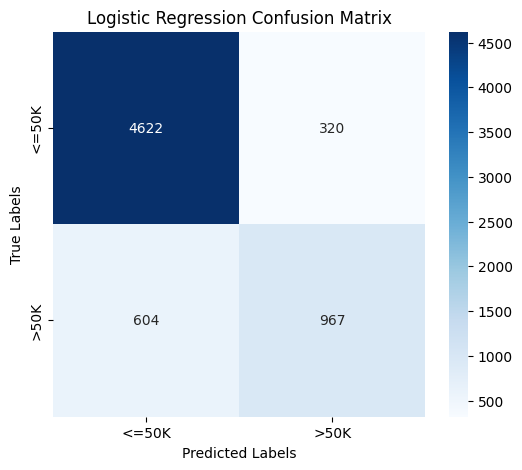

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Generate the confusion matrix data
# Make sure to run your predictions first: y_pred_lr = lr.predict(x_test_scaled)
cm = confusion_matrix(y_test_lr, y_pred_lr)

# 2. Plot using Seaborn's heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, 
    annot=True,          # Show the raw numbers in the boxes
    fmt="d",             # Format numbers as integers (not scientific notation)
    cmap="Blues",        # Nice blue color theme
    xticklabels=["<=50K", ">50K"], 
    yticklabels=["<=50K", ">50K"]
)

plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Logistic Regression Confusion Matrix")
plt.show()


## Now Decision Tree 

# decision we will use the data that was not encoded otherwise the tre would become too sparse

In [27]:
from sklearn.preprocessing import OrdinalEncoder

oe = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value = -1 )

cols = ['workclass',
 'marital_status',
 'occupation',
 'relationship',
 'race',
 'sex',
 'native_country']

df_tree  = df.copy()

df[cols] = oe.fit_transform(df[cols])
df.head()


df.income = le.fit_transform(df["income"])

# df.head()

In [28]:
x_train_tree,x_test_tree,y_train_tree, y_test_tree = train_test_split(df.drop("income",axis = 1), df.income, test_size=0.2, random_state=42)

In [29]:
## Now Decision Tree 

# decision we will use the data that was not encoded otherwise the tre would become too sparse


from sklearn.tree import DecisionTreeClassifier

tree =DecisionTreeClassifier()


tree.fit(x_train_tree, y_train_tree)
y_pred_tree =  tree.predict(x_test_tree)
print(accuracy_score(y_test_tree,y_pred_tree))
print(  classification_report(y_test_tree,y_pred_tree ))


0.8129894058037771
              precision    recall  f1-score   support

           0       0.88      0.87      0.88      4942
           1       0.61      0.63      0.62      1571

    accuracy                           0.81      6513
   macro avg       0.74      0.75      0.75      6513
weighted avg       0.82      0.81      0.81      6513



In [30]:
from xgboost import XGBClassifier

model = XGBClassifier()
model.fit(x_train_tree, y_train_tree)

y_pred_xgtree =  model.predict(x_test_tree)
print(accuracy_score(y_test_tree,y_pred_xgtree))
print(  classification_report(y_test_tree,y_pred_xgtree ))

0.8760939659143252
              precision    recall  f1-score   support

           0       0.90      0.94      0.92      4942
           1       0.78      0.68      0.73      1571

    accuracy                           0.88      6513
   macro avg       0.84      0.81      0.82      6513
weighted avg       0.87      0.88      0.87      6513



# Implementing Stacking 

In [34]:
estimators = [
    ('xg' ,XGBClassifier(enable_categorical =True)),
    ('tree', DecisionTreeClassifier())
]

stacking = StackingClassifier(estimators=estimators,final_estimator=LogisticRegression())
stacking.fit(x_train_tree,y_train_tree)
y_pred_stack = stacking.predict(x_test_tree)

print(accuracy_score(y_test_tree,y_pred_stack))
print(  classification_report(y_test_tree,y_pred_stack ))

0.8751727314601566
              precision    recall  f1-score   support

           0       0.90      0.94      0.92      4942
           1       0.78      0.67      0.72      1571

    accuracy                           0.88      6513
   macro avg       0.84      0.81      0.82      6513
weighted avg       0.87      0.88      0.87      6513

